In [ ]:
import torch
import torchvision
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
# select device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

In [ ]:
from google.colab import files
model_name = files.upload()

In [ ]:
import io

# Get the filename and content from the dictionary returned by files.upload()
uploaded_filename = list(model_name.keys())[0]
uploaded_content = model_name[uploaded_filename]

# Create a BytesIO object from the content
buffer = io.BytesIO(uploaded_content)

# Load the model from the buffer
model = torch.load(buffer, weights_only=False)

In [ ]:
from google.colab import files
model_name = files.upload()

In [35]:
model = torch.jit.load('watch_detector_yolo3u_traced.pth')

In [ ]:
model

In [ ]:
import cv2
import numpy as np

In [ ]:
def preprocess(img, img_size=416, border_color=114):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert to RGB

    # Resize with unchanged aspect ratio (letterbox)
    h, w = img.shape[:2]
    scale = min(img_size / h, img_size / w)
    nh, nw = int(h * scale), int(w * scale)
    img_resized = cv2.resize(img, (nw, nh))
    new_img = np.full((img_size, img_size, 3), border_color, dtype=np.uint8)
    new_img[:nh, :nw] = img_resized

    new_img = new_img.astype(np.float32) / 255.0 # normalize into 0-1
    new_img = np.transpose(new_img, (2, 0, 1)) # convert H,W,C to C,H,W
    tensor = torch.from_numpy(new_img).unsqueeze(0) # turn to tensor B,C,H,W
    return tensor, scale, nw, nh

In [36]:
img = cv2.imread("image.jpg")
x, scale, nw, nh = preprocess(img)
x = x.to("cuda")
y = model(x)
y = y[0].cpu()

In [30]:
def xywh2xyxy(x):
    y = x.clone()
    y[..., 0] = x[..., 0] - x[..., 2] / 2  # x1
    y[..., 1] = x[..., 1] - x[..., 3] / 2  # y1
    y[..., 2] = x[..., 0] + x[..., 2] / 2  # x2
    y[..., 3] = x[..., 1] + x[..., 3] / 2  # y2
    return y

In [31]:
# Non-Maximum Suppression
import time
import torchvision

def non_max_suppression(
    prediction,
    conf_thres: float = 0.25,
    iou_thres: float = 0.45,
    max_det: int = 300,
    nc: int = 0,  # number of classes (optional)
    max_time_img: float = 0.05,
    max_nms: int = 30000,
    max_wh: int = 7680,
):
    """Perform non-maximum suppression (NMS) on prediction results.

    Applies NMS to filter overlapping bounding boxes based on confidence and IoU thresholds. Supports multiple detection
    formats including standard boxes, rotated boxes, and masks.

    Args:
        prediction (torch.Tensor): Predictions with shape (batch_size, num_classes + 4 + num_masks, num_boxes)
            containing boxes, classes, and optional masks.
        conf_thres (float): Confidence threshold for filtering detections. Valid values are between 0.0 and 1.0.
        iou_thres (float): IoU threshold for NMS filtering. Valid values are between 0.0 and 1.0.
        classes (list[int], optional): List of class indices to consider. If None, all classes are considered.
        agnostic (bool): Whether to perform class-agnostic NMS.
        multi_label (bool): Whether each box can have multiple labels.
        labels (list[list[Union[int, float, torch.Tensor]]]): A priori labels for each image.
        max_det (int): Maximum number of detections to keep per image.
        nc (int): Number of classes. Indices after this are considered masks.
        max_time_img (float): Maximum time in seconds for processing one image.
        max_nms (int): Maximum number of boxes for NMS.
        max_wh (int): Maximum box width and height in pixels.
        end2end (bool): Whether the model is end-to-end and doesn't require NMS.
        return_idxs (bool): Whether to return the indices of kept detections.

    Returns:
        output (list[torch.Tensor]): List of detections per image with shape (num_boxes, 6 + num_masks) containing (x1,
            y1, x2, y2, confidence, class, mask1, mask2, ...).
        keepi (list[torch.Tensor]): Indices of kept detections if return_idxs=True.
    """
    # Checks
    assert 0 <= conf_thres <= 1, f"Invalid Confidence threshold {conf_thres}, valid values are between 0.0 and 1.0"
    assert 0 <= iou_thres <= 1, f"Invalid IoU {iou_thres}, valid values are between 0.0 and 1.0"
    if isinstance(prediction, (list, tuple)):  # YOLOv8 model in validation model, output = (inference_out, loss_out)
        prediction = prediction[0]  # select only inference output

    if prediction.shape[-1] == 6:  # end-to-end model (BNC, i.e. 1,300,6)
        output = [pred[pred[:, 4] > conf_thres][:max_det] for pred in prediction]
        return output

    bs = prediction.shape[0]  # batch size (BCN, i.e. 1,84,6300)
    nc = nc or (prediction.shape[1] - 4)  # number of classes
    extra = prediction.shape[1] - nc - 4  # number of extra info
    mi = 4 + nc  # mask start index
    xc = prediction[:, 4:mi].amax(1) > conf_thres  # candidates
    xinds = torch.arange(prediction.shape[-1], device=prediction.device).expand(bs, -1)[..., None]  # to track idxs

    # Settings
    # min_wh = 2  # (pixels) minimum box width and height
    time_limit = 2.0 + max_time_img * bs  # seconds to quit after

    prediction = prediction.transpose(-1, -2)  # shape(1,84,6300) to shape(1,6300,84)
    prediction[..., :4] = xywh2xyxy(prediction[..., :4])  # xywh to xyxy

    t = time.time()
    output = [torch.zeros((0, 6 + extra), device=prediction.device)] * bs
    keepi = [torch.zeros((0, 1), device=prediction.device)] * bs  # to store the kept idxs
    for xi, (x, xk) in enumerate(zip(prediction, xinds)):  # image index, (preds, preds indices)
        # Apply constraints
        # x[((x[:, 2:4] < min_wh) | (x[:, 2:4] > max_wh)).any(1), 4] = 0  # width-height
        filt = xc[xi]  # confidence
        x = x[filt]

        # If none remain process next image
        if not x.shape[0]:
            continue

        # Detections matrix nx6 (xyxy, conf, cls)
        box, cls, mask = x.split((4, nc, extra), 1)

        # best class only
        conf, j = cls.max(1, keepdim=True)
        filt = conf.view(-1) > conf_thres
        x = torch.cat((box, conf, j.float(), mask), 1)[filt]

        # Check shape
        n = x.shape[0]  # number of boxes
        if not n:  # no boxes
            continue
        if n > max_nms:  # excess boxes
            filt = x[:, 4].argsort(descending=True)[:max_nms]  # sort by confidence and remove excess boxes
            x = x[filt]

        c = x[:, 5:6] * max_wh  # classes
        scores = x[:, 4]  # scores

        boxes = x[:, :4] + c  # boxes (offset by class)
        # torchvision
        i = torchvision.ops.nms(boxes, scores, iou_thres)

        i = i[:max_det]  # limit detections

        output[xi] = x[i]
        if (time.time() - t) > time_limit:
            break  # time limit exceeded

    return output



In [49]:
def postprocess(predictions, orig, scale, nw, nh, conf_thres=0.75, iou_thres=0.45):
    pred = non_max_suppression(predictions, conf_thres=conf_thres, iou_thres=iou_thres)[0]
    oh, ow = orig[:2]
    pred[:, [0,2]] = pred[:, [0,2]] / nw * ow
    pred[:, [1,3]] = pred[:, [1,3]] / nh * oh
    return pred

In [37]:
pred = postprocess(y, img.shape, scale, nw, nh, conf_thres=0.75, iou_thres=0.45)

In [38]:
pred

tensor([[265.2208, 200.1853, 449.2554, 418.3273,   0.9876,   0.0000]])

In [39]:
def plot_one_box(xyxy, img, label=None, color=(0,255,0), line_thickness=None): # Plots one bounding box on the image
    # Calculate line thickness based on image size
    tl = line_thickness or round(0.002 * (img.shape[0] + img.shape[1]) / 2) + 1
    # Convert bounding box coordinates to integers
    pt1, pt2 = (int(xyxy[0]), int(xyxy[1])), (int(xyxy[2]), int(xyxy[3]))
    # Draw the bounding box rectangle on the image
    cv2.rectangle(img, pt1, pt2, color, thickness=tl)
    if label:
        # Calculate font thickness
        tf = max(tl - 1, 1)
        # Calculate text size
        t_size = cv2.getTextSize(label, 0, fontScale=tl / 3, thickness=tf)[0]
        # Calculate the coordinates for the label background rectangle
        pt3 = pt1[0] + t_size[0], pt1[1] - t_size[1] - 3
        # Draw the label background rectangle
        cv2.rectangle(img, pt1, pt3, color, cv2.FILLED)
        # Draw the label text
        cv2.putText(img, label, (pt1[0], pt1[1] - 2), 0, tl / 3, (0,0,0), thickness=tf)

In [40]:
names=['watch']

In [41]:
disp = np.copy(img)
for detection in pred:
    *xyxy, confidence, classid  = detection
    print(f'{confidence.item():.2f},{int(xyxy[0].item())},{int(xyxy[1].item())},{int(xyxy[2].item())},{int(xyxy[3].item())},{names[classid.int().item()]}')
    plot_one_box(xyxy, disp, label=names[classid.int().item()], color=(0,255,0))

0.99,265,200,449,418,watch


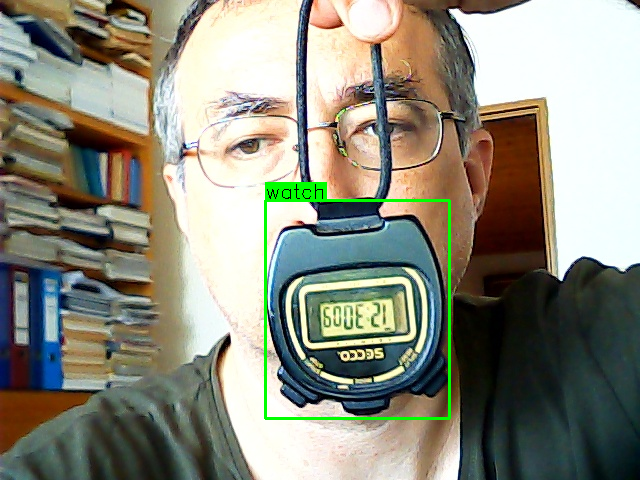

In [42]:
#display result
from google.colab.patches import cv2_imshow
cv2_imshow(disp)

In [43]:
# upload video
!wget http://www.agentspace.org/download/watch.avi
videofile = 'watch.avi'

--2025-11-24 23:24:10--  http://www.agentspace.org/download/watch.avi
Resolving www.agentspace.org (www.agentspace.org)... 62.168.101.9
Connecting to www.agentspace.org (www.agentspace.org)|62.168.101.9|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.agentspace.org/download/watch.avi [following]
--2025-11-24 23:24:11--  https://www.agentspace.org/download/watch.avi
Connecting to www.agentspace.org (www.agentspace.org)|62.168.101.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12008576 (11M) [video/x-msvideo]
Saving to: ‘watch.avi’

watch.avi           100%[===================>]  11.45M  3.42MB/s    in 3.3s    

2025-11-24 23:24:15 (3.42 MB/s) - ‘watch.avi’ saved [12008576/12008576]



In [50]:
#all in one
def process_image(img, conf_thresh=0.75, iou_thresh=0.45):
    x, scale, nw, nh = preprocess(img)
    x = x.to(device)
    y = model(x)
    y = y[0].cpu()
    pred = postprocess(y, img.shape, scale, nw, nh, conf_thresh, iou_thresh)
    disp = np.copy(img)
    for detection in pred:
        *xyxy, confidence, classid  = detection
        plot_one_box(xyxy, disp, label=names[classid.int().item()], color=(0,255,0))
    return disp

In [57]:
# process video
resultfile = 'result.avi'
video = cv2.VideoCapture(videofile)
fps = video.get(cv2.CAP_PROP_FPS)
hasFrame, frame = video.read()
out = cv2.VideoWriter()
out.open(resultfile,cv2.VideoWriter_fourcc('M','J','P','G'),fps,(frame.shape[1],frame.shape[0]))
while True:
    result = process_image(frame, conf_thresh=0.96, iou_thresh=0.45)
    out.write(result)
    hasFrame, frame = video.read()
    if not hasFrame:
        break
out.release()

In [58]:
# download video
files.download(resultfile)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>